In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path("../data")

In [2]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")
item_meta_df = pd.read_csv(DATA_DIR / "item_meta.csv")

print(train_df.shape, test_df.shape, item_meta_df.shape)

(147267, 3) (15460, 3) (7603, 15)


In [ ]:
n_users = train_df["user_id"].nunique()
n_items = train_df["item_id"].nunique()
n_interactions = len(train_df) # known by shape above
sparsity = 1 - n_interactions / (n_users * n_items)

print(n_users, n_items, sparsity)

23284 13441 147267 0.9995294386337454


In [10]:
n_dupes = train_df.duplicated(subset=["user_id", "item_id"]).sum()
print(n_dupes)

3954


count    23284.000000
mean         6.324815
std          4.183146
min          1.000000
25%          5.000000
50%          5.000000
75%          7.000000
max        124.000000
dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

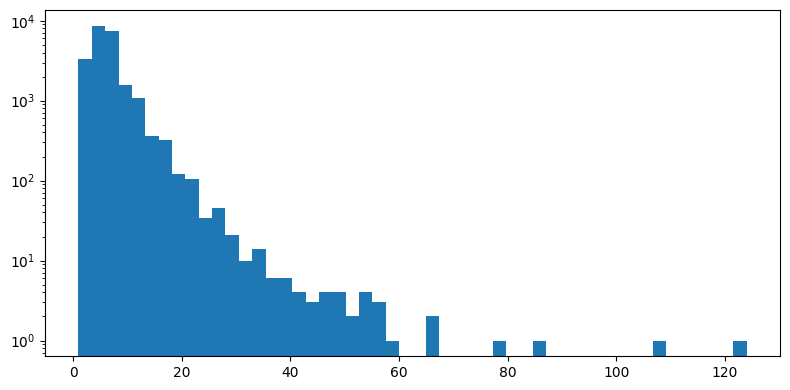

In [14]:
interactions_per_user = train_df.groupby("user_id").size()
print(interactions_per_user.describe())

plt.figure(figsize=(8, 4))
plt.hist(interactions_per_user, bins=50, log=True)
plt.tight_layout()
plt.show

count    13441.000000
mean        10.956551
std         16.326278
min          1.000000
25%          5.000000
50%          7.000000
75%         11.000000
max        559.000000
dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

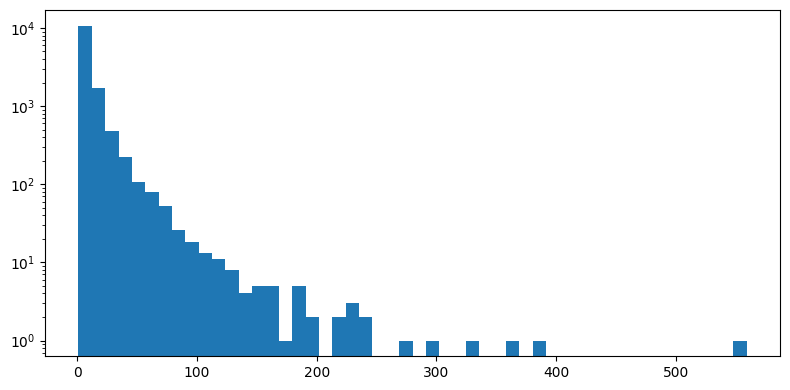

In [15]:
interactions_per_item = train_df.groupby("item_id").size()
print(interactions_per_item.describe())

plt.figure(figsize=(8, 4))
plt.hist(interactions_per_item, bins=50, log=True)
plt.tight_layout()
plt.show

In [19]:
test_users = set(test_df["user_id"].unique())
train_users = set(train_df["user_id"].unique())

cold_users = test_users  - train_users
print(f"{len(cold_users):,} ({len(cold_users)/len(test_users):.1%})")

0 (0.0%)


2002-05-09 02:04:47 → 2021-04-20 23:30:47.565000


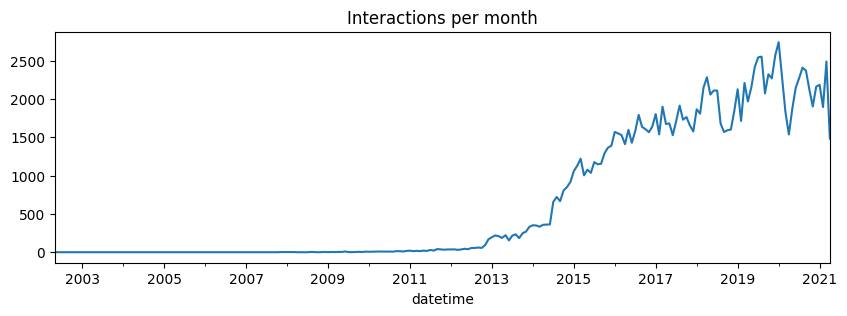

In [23]:
train_df["datetime"] = pd.to_datetime(train_df["timestamp"], unit="ms")
print(f"{train_df['datetime'].min()} → {train_df['datetime'].max()}")

train_df.set_index("datetime").resample("ME")["user_id"].count().plot(
    figsize=(10, 3), title = "Interactions per month"
)
plt.tight_layout
plt.show()

In [27]:
meta_items = set(item_meta_df["item_id"].unique())
train_items = set(train_df["item_id"].unique())

coverage = len(meta_items & train_items) / len(train_items)
print(f"{coverage:.1%}")

56.6%


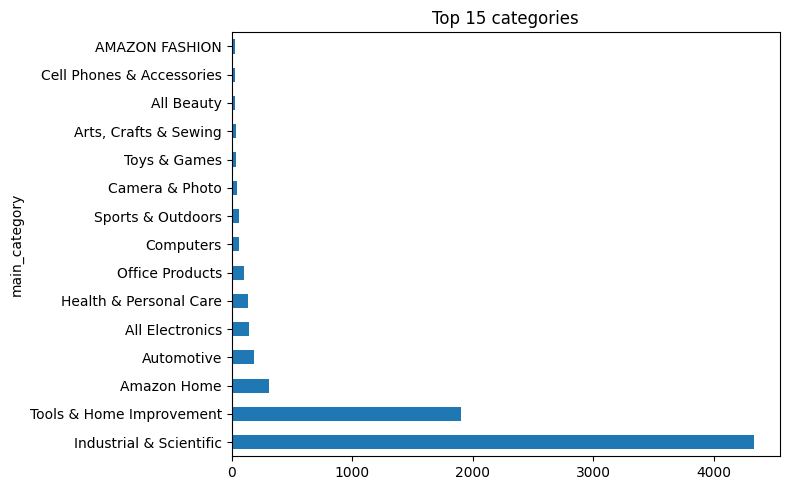

In [28]:
top_categories = (
    item_meta_df["main_category"].value_counts().head(15)
)

top_categories.plot(kind="barh", figsize=(8, 5), title="Top 15 categories")
plt.tight_layout()
plt.show()